# Insurance Claim Risk Ranking

Ranking policyholders by their probability of filing a claim in the next policy year, on 595K anonymized auto insurance policies.

**Business setting.** An insurer writing electric vehicle policies prices every customer against the same base rate. Claim frequency on EV books has been running above the portfolio average, and a flat rate means low risk drivers subsidize high risk ones until they leave. The pricing team needs a per-policy risk score that (a) ranks customers reliably and (b) is calibrated well enough to move premiums by up to ±40%.

**Data constraint.** The policy file has 57 features, but their meanings are withheld: only a group (`ind`, `reg`, `car`, `calc`) and a type suffix (`_bin`, `_cat`, none) are known. Every modeling decision here is driven by variable *type*, not domain knowledge.

**Sections**

1. Setup and data
2. Metadata: what kind of variable is each column
3. Target and evaluation protocol
4. Baseline
5. EDA and data decisions
6. Feature engineering experiments
7. Class imbalance experiments
8. Tuning
9. Final evaluation on the locked holdout
10. From score to premium
11. Interpretability
12. Export

## 1. Setup and data

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
N_FOLDS      = 5
DATA_DIR, FIG_DIR, OUT_DIR = "data", "figures", "outputs"
for d in (DATA_DIR, FIG_DIR, OUT_DIR):
    os.makedirs(d, exist_ok=True)

RESULTS = {}   # every number quoted in the README is written here

Data lives in a shared Google Drive folder. `gdown` pulls both files into `data/` if they are not already there; no Google account is needed.

In [2]:
DRIVE_FOLDER = "https://drive.google.com/drive/folders/1mv6Y5N13Pm5hBExm14kXL-U6qjwjtwGn?usp=sharing"

if not (os.path.exists(f"{DATA_DIR}/train.gz") and os.path.exists(f"{DATA_DIR}/test.gz")):
    import gdown
    gdown.download_folder(DRIVE_FOLDER, output=DATA_DIR, quiet=False, use_cookies=False)

train = pd.read_csv(f"{DATA_DIR}/train.gz", compression="gzip")
test  = pd.read_csv(f"{DATA_DIR}/test.gz",  compression="gzip")
print(f"train {train.shape}   test {test.shape}   test has target: {'target' in test.columns}")

Retrieving folder contents


Processing file 1gjkbqxFHJlAJulCFZF_YgiY0Ns4gmxiP test.gz
Processing file 14DxyGHODVWGtu4HObql6gHGnb4iM07IN train.gz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1gjkbqxFHJlAJulCFZF_YgiY0Ns4gmxiP
From (redirected): https://drive.google.com/uc?id=1gjkbqxFHJlAJulCFZF_YgiY0Ns4gmxiP&confirm=t&uuid=b08b92d1-7b91-4477-8ef7-8a4fe4e250de
To: /content/data/test.gz
100%|██████████| 40.7M/40.7M [00:00<00:00, 78.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=14DxyGHODVWGtu4HObql6gHGnb4iM07IN
From (redirected): https://drive.google.com/uc?id=14DxyGHODVWGtu4HObql6gHGnb4iM07IN&confirm=t&uuid=a846308d-7345-4a0f-bf24-0145a1babbe1
To: /content/data/train.gz
100%|██████████| 27.4M/27.4M [00:00<00:00, 109MB/s]
Download completed


train (595212, 59)   test (892816, 58)   test has target: False


Two things about the files decide the evaluation design:

- Missing values are coded as `-1`. They are converted to `NaN` so the model can treat them natively instead of as a numeric value that happens to sit below every real one.
- `test.gz` carries no `target` column, so it cannot be used to measure anything. All evaluation is carved out of `train.gz`: 80% becomes the **development set** where every experiment runs under cross-validation, and 20% becomes a **holdout** that is touched exactly once, in section 9.

In [3]:
FEATURES = [c for c in train.columns if c not in ("id", "target")]

train[FEATURES] = train[FEATURES].replace(-1, np.nan)
test[FEATURES]  = test[FEATURES].replace(-1, np.nan)

dev, hold = train_test_split(train, test_size=0.20, stratify=train["target"], random_state=RANDOM_STATE)
dev, hold = dev.reset_index(drop=True), hold.reset_index(drop=True)

X_dev,  y_dev  = dev[FEATURES],  dev["target"]
X_hold, y_hold = hold[FEATURES], hold["target"]

print(f"dev {X_dev.shape}  claim rate {y_dev.mean():.4f}")
print(f"holdout {X_hold.shape}  claim rate {y_hold.mean():.4f}")
RESULTS["n_train"], RESULTS["n_test"] = len(train), len(test)
RESULTS["n_dev"], RESULTS["n_hold"]   = len(dev), len(hold)

dev (476169, 57)  claim rate 0.0364
holdout (119043, 57)  claim rate 0.0364


## 2. Metadata

With feature names masked, the only usable structure is the naming convention: a group prefix and an optional type suffix. That is enough to classify every column, and the classification drives everything downstream (how missingness is read, what gets target-encoded, which columns go into the correlation check).

In [4]:
def classify(col):
    if col.endswith("_bin"):            return "binary"
    if col.endswith("_cat"):            return "nominal"
    if train[col].dtype == "float64":   return "continuous"
    return "ordinal"

meta = pd.DataFrame({
    "feature": FEATURES,
    "group":   [c.split("_")[1] for c in FEATURES],
    "type":    [classify(c) for c in FEATURES],
    "n_unique": [train[c].nunique() for c in FEATURES],
    "missing_rate": [train[c].isna().mean() for c in FEATURES],
}).set_index("feature")

pd.crosstab(meta["group"], meta["type"], margins=True)

type,binary,continuous,nominal,ordinal,All
group,,,,,
calc,6,3,0,11,20
car,0,5,11,0,16
ind,11,0,3,4,18
reg,0,3,0,0,3
All,17,11,14,15,57


In [5]:
meta[meta.missing_rate > 0].sort_values("missing_rate", ascending=False).round(4)

,group,type,n_unique,missing_rate
feature,,,,
ps_car_03_cat,car,nominal,2,0.6909
ps_car_05_cat,car,nominal,2,0.4478
ps_reg_03,reg,continuous,5012,0.1811
ps_car_14,car,continuous,849,0.0716
ps_car_07_cat,car,nominal,2,0.0193
ps_ind_05_cat,ind,nominal,7,0.0098
ps_car_09_cat,car,nominal,5,0.0010
ps_ind_02_cat,ind,nominal,4,0.0004
ps_car_01_cat,car,nominal,12,0.0002


## 3. Target and evaluation protocol

3.6% of policies file a claim. Two consequences follow before any model is built.

**Accuracy is meaningless.** Predicting "no claim" for everyone scores 96.4%. Every metric used here is either rank based (AUC, Gini, capture rate) or reports its own baseline (AUPRC, whose random level equals the claim rate).

**The evaluation protocol is fixed now and never changes.** Every experiment in sections 4 to 8 produces *out of fold* predictions under the same 5-fold stratified split of the development set, and is scored with the same functions. Anything that has to be fit (target encodings, resampling, feature selection) happens inside the training portion of each fold. The validation portion keeps the real 3.6% claim rate.

claim rate 0.0364   negatives per positive 26.44
accuracy of predicting 'no claim' for everyone: 0.9636


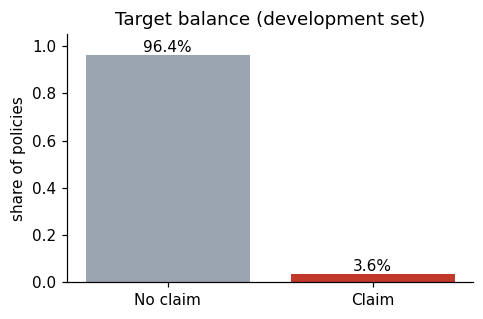

In [6]:
claim_rate = y_dev.mean()
RESULTS["claim_rate"] = round(float(claim_rate), 5)
RESULTS["neg_pos_ratio"] = round(float((1 - claim_rate) / claim_rate), 2)
print(f"claim rate {claim_rate:.4f}   negatives per positive {(1-claim_rate)/claim_rate:.2f}")
print(f"accuracy of predicting 'no claim' for everyone: {1-claim_rate:.4f}")

fig, ax = plt.subplots(figsize=(4.5, 3))
ax.bar(["No claim", "Claim"], [1 - claim_rate, claim_rate], color=["#9aa5b1", "#c0392b"])
for i, v in enumerate([1 - claim_rate, claim_rate]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
ax.set_ylabel("share of policies"); ax.set_ylim(0, 1.05); ax.set_title("Target balance (development set)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/01_target_balance.png"); plt.show()

In [7]:
def capture_at_k(y_true, score, k=0.05):
    # share of all claims that fall inside the top k% of predicted risk
    y_true = np.asarray(y_true); n = int(len(score) * k)
    top = np.argsort(score)[::-1][:n]
    return y_true[top].sum() / y_true.sum()

def evaluate(y_true, score, k=0.05):
    auc = roc_auc_score(y_true, score)
    cap = capture_at_k(y_true, score, k)
    return {"auc": auc, "gini": 2 * auc - 1,
            "auprc": average_precision_score(y_true, score),
            "capture_5pct": cap, "lift_5pct": cap / k,
            "mean_pred": float(np.mean(score))}

# ---- target encoding: fit on one set of rows, apply to another --------------
def target_encode(fit_col, fit_y, apply_col, min_samples=20, smoothing=10):
    prior = fit_y.mean()
    stats = pd.DataFrame({"c": fit_col.values, "y": fit_y.values}).groupby("c")["y"].agg(["mean", "count"])
    w = 1 / (1 + np.exp(-(stats["count"] - min_samples) / smoothing))
    mapping = prior * (1 - w) + stats["mean"] * w
    return apply_col.map(mapping).fillna(prior)

def target_encode_oof(col, y, n_splits=5, seed=0, **kw):
    # encoding for training rows: each row is encoded with statistics from the other folds only
    enc = pd.Series(np.nan, index=col.index)
    skf = StratifiedKFold(n_splits, shuffle=True, random_state=seed)
    for fit_idx, enc_idx in skf.split(col, y):
        enc.iloc[enc_idx] = target_encode(col.iloc[fit_idx], y.iloc[fit_idx], col.iloc[enc_idx], **kw).values
    return enc

# ---- the one cross-validation loop every experiment goes through ------------
def run_cv(X, y, params, te_cols=(), sampler=None, n_folds=N_FOLDS, seed=RANDOM_STATE):
    oof = np.zeros(len(y))
    skf = StratifiedKFold(n_folds, shuffle=True, random_state=seed)
    for tr, va in skf.split(X, y):
        Xtr, ytr, Xva = X.iloc[tr].copy(), y.iloc[tr], X.iloc[va].copy()
        for c in te_cols:                                   # fit encoding on training rows only
            Xtr[c + "_te"] = target_encode_oof(Xtr[c], ytr).values
            Xva[c + "_te"] = target_encode(Xtr[c], ytr, Xva[c]).values
        if sampler is not None:                             # resample training rows only
            Xtr, ytr = sampler(Xtr, ytr)
        model = XGBClassifier(**params).fit(Xtr, ytr)
        oof[va] = model.predict_proba(Xva)[:, 1]
    return oof

BASE_PARAMS = dict(n_estimators=300, learning_rate=0.05, max_depth=4,
                   subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
                   reg_lambda=1.0, tree_method="hist", eval_metric="auc",
                   n_jobs=-1, random_state=RANDOM_STATE)

EXPERIMENTS = {}   # name -> metrics dict
def log(name, y_true, score, **extra):
    m = evaluate(y_true, score); m.update(extra); EXPERIMENTS[name] = m
    print(f"{name:32s} AUC {m['auc']:.4f}  Gini {m['gini']:.4f}  AUPRC {m['auprc']:.4f}  "
          f"capture@5% {m['capture_5pct']:.3f}  mean_pred {m['mean_pred']:.3f}")
    return m

## 4. Baseline

All 57 features as they come, missing values left to the model, no encoding, no resampling, default-ish parameters. Everything after this is measured as a delta from here.

In [34]:
# --- naive baseline: logistic regression, same 5-fold protocol ---------------
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr_pipe = make_pipeline(SimpleImputer(strategy="median"), StandardScaler(),
                        LogisticRegression(C=0.1, max_iter=1000, n_jobs=-1))

oof_lr = np.zeros(len(y_dev))
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
for tr, va in skf.split(X_dev, y_dev):
    lr_pipe.fit(X_dev.iloc[tr], y_dev.iloc[tr])          # imputer and scaler fit on training fold only
    oof_lr[va] = lr_pipe.predict_proba(X_dev.iloc[va])[:, 1]

lr_base = log("logistic regression (naive)", y_dev, oof_lr)
RESULTS["cv_logistic"] = {k: round(float(v), 4) for k, v in lr_base.items()}

logistic regression (naive)      AUC 0.6193  Gini 0.2386  AUPRC 0.0586  capture@5% 0.109  mean_pred 0.036


In [8]:
t0 = time.time()
oof_base = run_cv(X_dev, y_dev, BASE_PARAMS)
base = log("baseline", y_dev, oof_base)
print(f"{time.time()-t0:.0f}s")

baseline                         AUC 0.6396  Gini 0.2791  AUPRC 0.0662  capture@5% 0.124  mean_pred 0.036
65s


## 5. EDA and data decisions

Three questions, each answered with a number that changes a downstream decision.

### 5.1 Is missingness random?

If a value is missing at random, the right move is to impute or ignore it. If policies with a missing value claim at a different rate than policies without, the *fact* of missingness is itself a feature and must not be imputed away.

In [9]:
rows = []
for c in meta.index[meta.missing_rate > 0]:
    m = X_dev[c].isna()
    rows.append({"feature": c, "missing_rate": m.mean(),
                 "claim_rate_missing": y_dev[m].mean(), "claim_rate_present": y_dev[~m].mean()})
miss = pd.DataFrame(rows).set_index("feature")
miss["ratio"] = miss.claim_rate_missing / miss.claim_rate_present
miss = miss.sort_values("ratio", ascending=False)
RESULTS["missing_vs_target"] = miss.round(4).to_dict("index")
miss.round(4)

,missing_rate,claim_rate_missing,claim_rate_present,ratio
feature,,,,
ps_ind_04_cat,0.0001,0.3871,0.0364,10.6341
ps_car_01_cat,0.0002,0.2976,0.0364,8.1761
ps_ind_02_cat,0.0003,0.1818,0.0364,4.9955
ps_car_09_cat,0.0010,0.0852,0.0364,2.3393
ps_ind_05_cat,0.0097,0.0803,0.0360,2.2298
ps_car_07_cat,0.0192,0.0784,0.0356,2.2000
ps_car_14,0.0718,0.0401,0.0362,1.1102
ps_car_05_cat,0.4476,0.0320,0.0401,0.7982
ps_reg_03,0.1812,0.0283,0.0382,0.7404


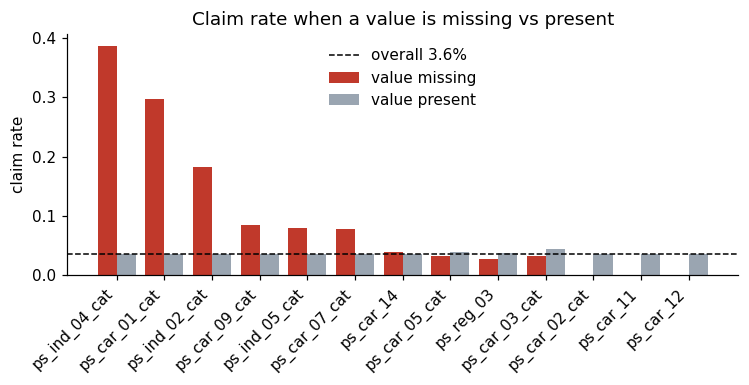

In [10]:
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(len(miss))
ax.bar(x - 0.2, miss.claim_rate_missing, 0.4, label="value missing", color="#c0392b")
ax.bar(x + 0.2, miss.claim_rate_present, 0.4, label="value present", color="#9aa5b1")
ax.axhline(claim_rate, ls="--", lw=1, color="k", label=f"overall {claim_rate:.1%}")
ax.set_xticks(x); ax.set_xticklabels(miss.index, rotation=45, ha="right")
ax.set_ylabel("claim rate"); ax.set_title("Claim rate when a value is missing vs present"); ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/02_missing_vs_target.png"); plt.show()

Missingness is informative in both directions. Policies missing `ps_car_07_cat` or `ps_ind_05_cat` claim at roughly twice the base rate; policies missing `ps_car_03_cat` or `ps_reg_03` claim *less* than average. Two decisions follow:

- No imputation. `NaN` stays `NaN` and the tree model learns a default direction per split.
- Nothing is dropped for having a high missing rate. `ps_car_03_cat` is 69% missing and would be a routine deletion, but the missing/present split carries signal.

### 5.2 Which features carry any signal on their own?

A single-feature AUC (the AUC you get ranking policies by one raw column) is a cheap, model-free test of whether a column is worth anything. It is especially useful for the 20 `calc` features, whose summary statistics look like draws from a random generator.

In [11]:
single = {}
for c in FEATURES:
    v = X_dev[c].fillna(X_dev[c].median())
    a = roc_auc_score(y_dev, v)
    single[c] = max(a, 1 - a)
single = pd.Series(single).sort_values(ascending=False)
single_by_group = single.groupby(meta.loc[single.index, "group"]).agg(["mean", "max"]).round(4)
RESULTS["single_feature_auc_by_group"] = single_by_group.to_dict("index")
single_by_group

,mean,max
group,,
calc,0.5014,0.5038
car,0.5232,0.5759
ind,0.5164,0.5444
reg,0.5457,0.5512


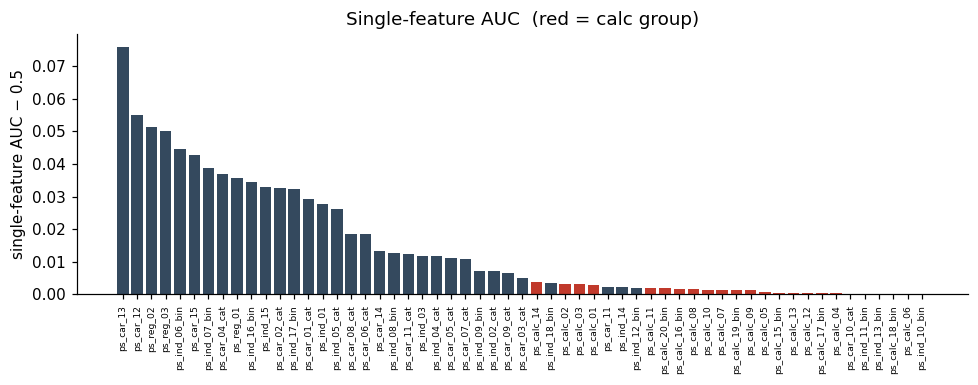

In [12]:
fig, ax = plt.subplots(figsize=(9, 3.6))
colors = ["#c0392b" if meta.loc[c, "group"] == "calc" else "#34495e" for c in single.index]
ax.bar(range(len(single)), single.values - 0.5, color=colors)
ax.set_xticks(range(len(single))); ax.set_xticklabels(single.index, rotation=90, fontsize=6)
ax.set_ylabel("single-feature AUC − 0.5"); ax.set_title("Single-feature AUC  (red = calc group)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/03_single_feature_auc.png"); plt.show()

In [13]:
calc_cols = [c for c in FEATURES if c.startswith("ps_calc")]
oof_nocalc = run_cv(X_dev.drop(columns=calc_cols), y_dev, BASE_PARAMS)
log("drop calc group", y_dev, oof_nocalc, delta_auc=evaluate(y_dev, oof_nocalc)["auc"] - base["auc"])

drop calc group                  AUC 0.6411  Gini 0.2823  AUPRC 0.0666  capture@5% 0.126  mean_pred 0.036


{'auc': np.float64(0.6411494918423555),
 'gini': np.float64(0.28229898368471096),
 'auprc': np.float64(0.06657080295955478),
 'capture_5pct': np.float64(0.12630365888792855),
 'lift_5pct': np.float64(2.5260731777585708),
 'mean_pred': 0.0364330541290818,
 'delta_auc': np.float64(0.0015909008881928033)}

Every `calc` feature sits within noise of AUC 0.5 on its own, and removing all 20 at once leaves the cross-validated AUC unchanged. They are dropped: 20 fewer columns, same model.

### 5.3 Where is the redundancy?

Several `car` and `reg` features move together. For a tree model this is not a modeling problem (a tree picks one feature per split and ignores its twins), but it matters for reading feature importance in section 11, where credit gets divided among correlated columns.

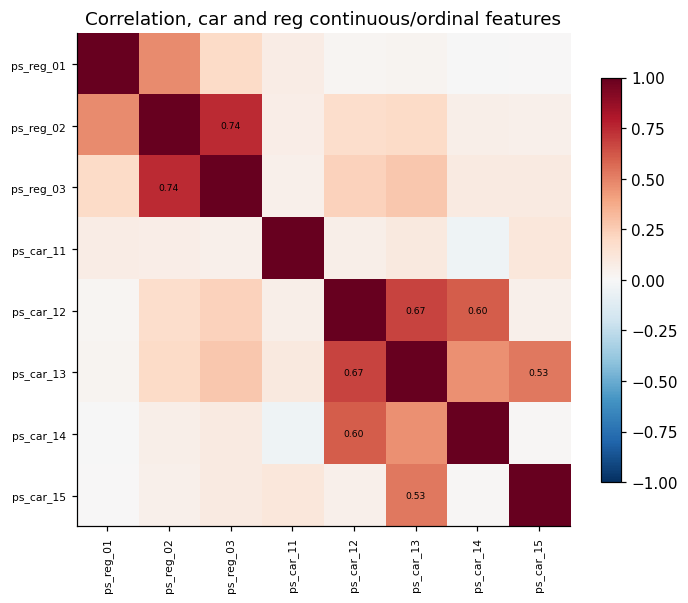

[('ps_reg_02', 'ps_reg_03', np.float64(0.7443263497470349)),
 ('ps_car_12', 'ps_car_13', np.float64(0.6722309491410783)),
 ('ps_car_12', 'ps_car_14', np.float64(0.6027313637609495)),
 ('ps_car_13', 'ps_car_15', np.float64(0.5301686512900068))]

In [14]:
cont = [c for c in FEATURES if meta.loc[c, "type"] in ("continuous", "ordinal") and meta.loc[c, "group"] in ("car", "reg")]
corr = X_dev[cont].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cont))); ax.set_xticklabels(cont, rotation=90, fontsize=7)
ax.set_yticks(range(len(cont))); ax.set_yticklabels(cont, fontsize=7)
for i in range(len(cont)):
    for j in range(len(cont)):
        if i != j and abs(corr.iloc[i, j]) > 0.5:
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6)
plt.colorbar(im, ax=ax, shrink=0.8); ax.set_title("Correlation, car and reg continuous/ordinal features")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/04_correlation_car_reg.png"); plt.show()

pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(cont) for b in cont[i+1:] if abs(corr.loc[a, b]) > 0.5]
RESULTS["correlated_pairs"] = [(a, b, round(float(r), 3)) for a, b, r in pairs]
pairs

## 6. Feature engineering experiments

One change at a time, each scored against the baseline under the identical protocol. Changes that do not move AUC are rejected even when they are conventional.

Starting point: the 37 non-`calc` features.

In [15]:
X_fe = X_dev.drop(columns=calc_cols)
fe_results = {"baseline (37 features)": evaluate(y_dev, oof_nocalc)}

# --- A. explicit missing indicators for the informative columns ----------------
ind_cols = miss.index[(miss.ratio > 1.3) | (miss.ratio < 0.8)].tolist()
def add_indicators(X_sub, X_all):
    # X_sub: the modeling columns; X_all: all 57 raw columns for the same rows (for the missing count)
    X = X_sub.copy()
    for c in ind_cols: X[c + "_isna"] = X[c].isna().astype(np.int8)
    X["n_missing"] = X_all.isna().sum(axis=1).values
    return X
X_A = add_indicators(X_fe, X_dev)
oof_A = run_cv(X_A, y_dev, BASE_PARAMS)
fe_results["+ missing indicators"] = evaluate(y_dev, oof_A)

# --- B. out-of-fold target encoding for the high-cardinality nominal -----------
hi_card = [c for c in X_fe.columns if c.endswith("_cat") and X_fe[c].nunique() > 20]
print("high-cardinality nominal:", hi_card)
oof_B = run_cv(X_A, y_dev, BASE_PARAMS, te_cols=hi_card)
fe_results["+ target encoding"] = evaluate(y_dev, oof_B)

# --- C. pairwise products of the continuous features ---------------------------
cont_cols = [c for c in X_fe.columns if meta.loc[c, "type"] == "continuous"]
def add_products(X):
    X = X.copy()
    for i, a in enumerate(cont_cols):
        for b in cont_cols[i+1:]:
            X[f"{a}_x_{b}"] = X[a] * X[b]
    return X
X_C = add_products(X_A)
print(f"with products: {X_C.shape[1]} columns")
oof_C = run_cv(X_C, y_dev, BASE_PARAMS, te_cols=hi_card)
fe_results["+ pairwise products"] = evaluate(y_dev, oof_C)

high-cardinality nominal: ['ps_car_11_cat']
with products: 77 columns


In [16]:
fe_table = pd.DataFrame(fe_results).T[["auc", "gini", "auprc", "capture_5pct"]]
fe_table["delta_auc"] = fe_table["auc"] - fe_table.loc["baseline (37 features)", "auc"]
RESULTS["feature_experiments"] = fe_table.round(4).to_dict("index")
fe_table.round(4)

,auc,gini,auprc,capture_5pct,delta_auc
baseline (37 features),0.6411,0.2823,0.0666,0.1263,0.0000
+ missing indicators,0.6408,0.2816,0.0664,0.1270,-0.0004
+ target encoding,0.6412,0.2824,0.0668,0.1277,0.0001
+ pairwise products,0.6402,0.2803,0.0664,0.1268,-0.0010


Missing indicators and the out-of-fold target encoding of `ps_car_11_cat` (104 levels) each add a small amount; pairwise products add nothing, because a tree that splits on feature A and then on feature B inside that branch has already represented A×B. The final feature set is the 37 non-`calc` columns plus the indicators plus the target encoding.

The target encoding uses three protections against overfitting a category to its own labels: a count-based smoothing toward the global rate (so a level with 3 policies cannot encode to its own claim rate), out-of-fold computation for training rows (no row's label contributes to its own encoding), and fitting only on the training portion of each outer fold.

In [17]:
FINAL_FEATURES = list(X_A.columns)
TE_COLS = hi_card
X_final = X_A
oof_fe = oof_B
fe_best = log("final features", y_dev, oof_fe)
RESULTS["n_final_features"] = len(FINAL_FEATURES) + len(TE_COLS)

final features                   AUC 0.6412  Gini 0.2824  AUPRC 0.0668  capture@5% 0.128  mean_pred 0.036


## 7. Class imbalance experiments

The usual reflex on a 26:1 dataset is to resample. Whether that helps is an empirical question with two parts: does the ranking improve, and what happens to the probabilities? Four treatments are compared under the same protocol. Each is applied inside the training fold only; the validation fold always keeps its real 3.6% claim rate.

| Treatment | What it does |
|---|---|
| none | train on the data as is |
| class weight | `scale_pos_weight = 26`, upweights positives in the loss |
| undersample | randomly drop negatives until 1 positive : 5 negatives |
| undersample + SMOTE | as above, then synthesize positives to 1 : 2 |

In [18]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import BorderlineSMOTE

def undersample(X, y):
    return RandomUnderSampler(sampling_strategy=0.2, random_state=RANDOM_STATE).fit_resample(X, y)

def undersample_smote(X, y):
    Xu, yu = undersample(X, y)
    Xu = Xu.fillna(Xu.median())            # SMOTE interpolates and cannot take NaN
    return BorderlineSMOTE(sampling_strategy=0.5, random_state=RANDOM_STATE).fit_resample(Xu, yu)

imb = {}
imb["none"] = oof_fe
imb["class weight"] = run_cv(X_final, y_dev, {**BASE_PARAMS, "scale_pos_weight": RESULTS["neg_pos_ratio"]}, te_cols=TE_COLS)
imb["undersample"] = run_cv(X_final, y_dev, BASE_PARAMS, te_cols=TE_COLS, sampler=undersample)
imb["undersample + SMOTE"] = run_cv(X_final, y_dev, BASE_PARAMS, te_cols=TE_COLS, sampler=undersample_smote)

imb_table = pd.DataFrame({k: evaluate(y_dev, v) for k, v in imb.items()}).T
RESULTS["imbalance_experiments"] = imb_table.round(4).to_dict("index")
imb_table.round(4)

,auc,gini,auprc,capture_5pct,lift_5pct,mean_pred
none,0.6412,0.2824,0.0668,0.1277,2.5549,0.0364
class weight,0.6402,0.2805,0.0662,0.1256,2.5111,0.4622
undersample,0.6402,0.2803,0.0658,0.1241,2.4823,0.1615
undersample + SMOTE,0.6318,0.2635,0.0620,0.1153,2.3060,0.1782


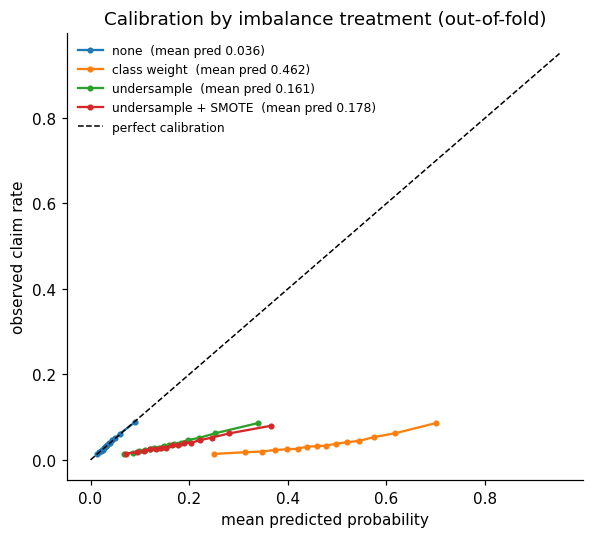

In [19]:
fig, ax = plt.subplots(figsize=(5.5, 5))
for name, p in imb.items():
    frac_pos, mean_pred = calibration_curve(y_dev, p, n_bins=15, strategy="quantile")
    ax.plot(mean_pred, frac_pos, marker="o", ms=3, label=f"{name}  (mean pred {p.mean():.3f})")
lim = max(p.max() for p in imb.values())
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect calibration")
ax.set_xlabel("mean predicted probability"); ax.set_ylabel("observed claim rate")
ax.set_title("Calibration by imbalance treatment (out-of-fold)"); ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/05_imbalance_calibration.png"); plt.show()

None of the treatments improves the ranking, and every one of them breaks calibration: the resampled and reweighted models predict an average claim probability several times the true rate, because they were trained on a world where claims are common. The ranking a gradient-boosted model learns is not sensitive to the class ratio, so there is nothing for resampling to fix, and the probabilities it damages are exactly what section 10 needs.

Decision: no resampling and no class weighting. The model is trained on the real distribution.

## 8. Tuning

Two steps. Early stopping on one fold finds how many trees the data supports at a given learning rate; a small grid over depth and leaf size then checks whether the structure is right. The grid is deliberately small: on a dataset with this little signal, tuning moves the third decimal.

best iteration at learning_rate 0.03: 678


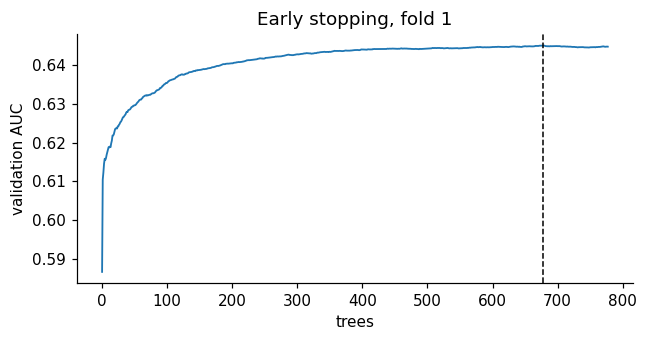

In [20]:
skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
tr, va = next(skf.split(X_final, y_dev))
Xtr, ytr, Xva, yva = X_final.iloc[tr].copy(), y_dev.iloc[tr], X_final.iloc[va].copy(), y_dev.iloc[va]
for c in TE_COLS:
    Xtr[c + "_te"] = target_encode_oof(Xtr[c], ytr).values
    Xva[c + "_te"] = target_encode(Xtr[c], ytr, Xva[c]).values

es_params = {**BASE_PARAMS, "n_estimators": 3000, "learning_rate": 0.03, "early_stopping_rounds": 100}
es_model = XGBClassifier(**es_params).fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
best_rounds = int(es_model.best_iteration) + 1
print(f"best iteration at learning_rate 0.03: {best_rounds}")

hist = es_model.evals_result()["validation_0"]["auc"]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(hist, lw=1.2); ax.axvline(best_rounds, ls="--", color="k", lw=1)
ax.set_xlabel("trees"); ax.set_ylabel("validation AUC"); ax.set_title("Early stopping, fold 1")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/06_early_stopping.png"); plt.show()
RESULTS["best_rounds"] = best_rounds

In [21]:
grid = [dict(max_depth=3, min_child_weight=5), dict(max_depth=4, min_child_weight=5),
        dict(max_depth=5, min_child_weight=5), dict(max_depth=4, min_child_weight=20)]
tune = {}
for g in grid:
    p = {**BASE_PARAMS, "learning_rate": 0.03, "n_estimators": best_rounds, **g}
    oof = run_cv(X_final, y_dev, p, te_cols=TE_COLS, n_folds=3)
    tune[str(g)] = evaluate(y_dev, oof)
    print(f"{str(g):48s} AUC {tune[str(g)]['auc']:.4f}")
tune_table = pd.DataFrame(tune).T[["auc", "gini", "capture_5pct"]].round(4)
best_cfg = grid[int(np.argmax(tune_table["auc"].values))]
FINAL_PARAMS = {**BASE_PARAMS, "learning_rate": 0.03, "n_estimators": best_rounds, **best_cfg}
RESULTS["tuning"] = tune_table.to_dict("index"); RESULTS["final_params"] = {k: v for k, v in FINAL_PARAMS.items() if k not in ("n_jobs", "tree_method", "eval_metric")}
print("final params:", best_cfg, "n_estimators", best_rounds)

{'max_depth': 3, 'min_child_weight': 5}          AUC 0.6397
{'max_depth': 4, 'min_child_weight': 5}          AUC 0.6403
{'max_depth': 5, 'min_child_weight': 5}          AUC 0.6385
{'max_depth': 4, 'min_child_weight': 20}         AUC 0.6404
final params: {'max_depth': 4, 'min_child_weight': 20} n_estimators 678


In [22]:
oof_final = run_cv(X_final, y_dev, FINAL_PARAMS, te_cols=TE_COLS)
final_cv = log("final (tuned, 5-fold CV)", y_dev, oof_final)
if final_cv["auc"] < fe_best["auc"]:          # tuning must earn its place under the same protocol
    print("tuned configuration did not beat the untuned one; keeping the untuned parameters")
    FINAL_PARAMS, oof_final, final_cv = dict(BASE_PARAMS), oof_fe, fe_best
RESULTS["cv_final"] = {k: round(float(v), 4) for k, v in final_cv.items()}
RESULTS["cv_baseline"] = {k: round(float(v), 4) for k, v in base.items()}

final (tuned, 5-fold CV)         AUC 0.6419  Gini 0.2837  AUPRC 0.0668  capture@5% 0.127  mean_pred 0.036


## 9. Final evaluation on the locked holdout

The model is refit on the full development set with the final features and parameters, and scored once on the 20% holdout that has not been touched since section 1. These are the numbers the README reports.

In [23]:
X_dev_final  = X_final.copy()
X_hold_final = add_indicators(X_hold.drop(columns=calc_cols), X_hold)
for c in TE_COLS:
    X_dev_final[c + "_te"]  = target_encode_oof(X_dev_final[c], y_dev).values
    X_hold_final[c + "_te"] = target_encode(X_dev_final[c], y_dev, X_hold_final[c]).values

final_model = XGBClassifier(**FINAL_PARAMS).fit(X_dev_final, y_dev)
p_hold = final_model.predict_proba(X_hold_final[X_dev_final.columns])[:, 1]

hold_metrics = evaluate(y_hold, p_hold)
RESULTS["holdout"] = {k: round(float(v), 4) for k, v in hold_metrics.items()}
for k in (0.01, 0.05, 0.10, 0.20):
    RESULTS["holdout"][f"capture_{int(k*100)}pct"] = round(float(capture_at_k(y_hold, p_hold, k)), 4)
pd.Series(RESULTS["holdout"])

,0
auc,0.6414
gini,0.2828
auprc,0.0686
capture_5pct,0.1277
lift_5pct,2.5536
mean_pred,0.0365
capture_1pct,0.0385
capture_10pct,0.2169
capture_20pct,0.3671


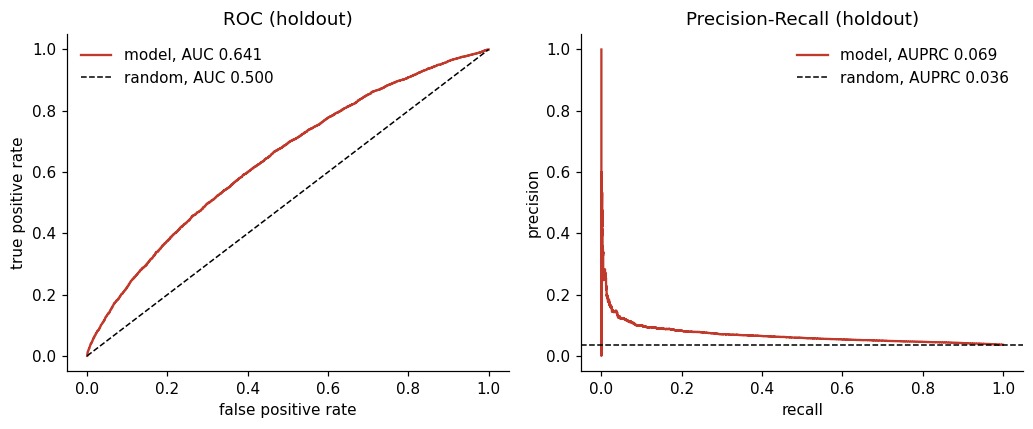

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
fpr, tpr, _ = roc_curve(y_hold, p_hold)
axes[0].plot(fpr, tpr, color="#c0392b", label=f"model, AUC {hold_metrics['auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="random, AUC 0.500")
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate"); axes[0].set_title("ROC (holdout)"); axes[0].legend(frameon=False)
prec, rec, _ = precision_recall_curve(y_hold, p_hold)
axes[1].plot(rec, prec, color="#c0392b", label=f"model, AUPRC {hold_metrics['auprc']:.3f}")
axes[1].axhline(y_hold.mean(), ls="--", color="k", lw=1, label=f"random, AUPRC {y_hold.mean():.3f}")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision"); axes[1].set_title("Precision-Recall (holdout)"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/07_roc_pr_holdout.png"); plt.show()

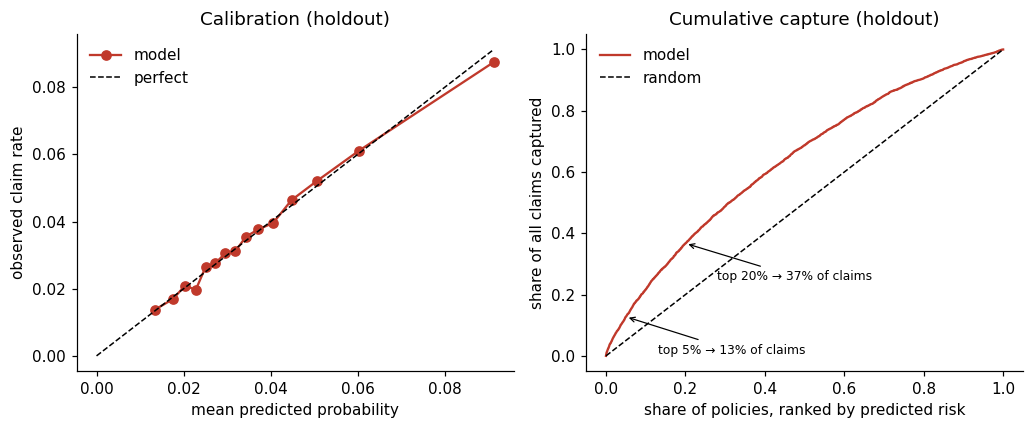

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
frac_pos, mean_pred = calibration_curve(y_hold, p_hold, n_bins=15, strategy="quantile")
axes[0].plot(mean_pred, frac_pos, marker="o", color="#c0392b", label="model")
axes[0].plot([0, mean_pred.max()], [0, mean_pred.max()], "k--", lw=1, label="perfect")
axes[0].set_xlabel("mean predicted probability"); axes[0].set_ylabel("observed claim rate"); axes[0].set_title("Calibration (holdout)"); axes[0].legend(frameon=False)

order = np.argsort(p_hold)[::-1]; cum = np.cumsum(y_hold.values[order]) / y_hold.sum()
share = np.arange(1, len(cum) + 1) / len(cum)
axes[1].plot(share, cum, color="#c0392b", label="model")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="random")
for k in (0.05, 0.20):
    axes[1].annotate(f"top {int(k*100)}% → {capture_at_k(y_hold, p_hold, k):.0%} of claims", (k, capture_at_k(y_hold, p_hold, k)),
                     xytext=(k + 0.08, capture_at_k(y_hold, p_hold, k) - 0.12), arrowprops=dict(arrowstyle="->", lw=0.8), fontsize=8)
axes[1].set_xlabel("share of policies, ranked by predicted risk"); axes[1].set_ylabel("share of all claims captured"); axes[1].set_title("Cumulative capture (holdout)"); axes[1].legend(frameon=False)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/08_calibration_lift_holdout.png"); plt.show()

## 10. From score to premium

A ranking is only useful once it becomes a pricing action. The holdout is cut into ten risk deciles; each decile's observed claim rate gives the relative risk, and a premium factor is assigned that runs from 0.6× (lowest decile) to 1.4× (highest), rescaled so the book's total premium is unchanged.

The 65% capture rate in the original brief (top 5% of policies containing 65% of claims) is also checked here against what the data can support.

In [26]:
dec = pd.DataFrame({"p": p_hold, "y": y_hold.values})
dec["decile"] = pd.qcut(dec["p"].rank(method="first"), 10, labels=range(1, 11))
tab = dec.groupby("decile").agg(policies=("y", "size"), claim_rate=("y", "mean"), mean_pred=("p", "mean"))
tab["relative_risk"] = tab.claim_rate / y_hold.mean()
tab["share_of_claims"] = dec.groupby("decile")["y"].sum() / y_hold.sum()
raw_factor = np.linspace(0.6, 1.4, 10)
tab["premium_factor"] = raw_factor / np.average(raw_factor, weights=tab.policies)   # revenue neutral
RESULTS["decile_table"] = tab.round(4).reset_index().astype({"decile": int}).to_dict("records")
RESULTS["top_vs_bottom_decile_risk"] = round(float(tab.claim_rate.iloc[-1] / tab.claim_rate.iloc[0]), 2)
tab.round(4)

,policies,claim_rate,mean_pred,relative_risk,share_of_claims,premium_factor
decile,,,,,,
1,11905,0.0143,0.0145,0.3918,0.0392,0.6000
2,11904,0.0201,0.0197,0.5508,0.0551,0.6889
3,11904,0.0207,0.0234,0.5670,0.0567,0.7778
4,11904,0.0285,0.0267,0.7813,0.0781,0.8667
5,11905,0.0305,0.0301,0.8365,0.0837,0.9556
6,11904,0.0343,0.0337,0.9403,0.0940,1.0444
7,11904,0.0384,0.0380,1.0533,0.1053,1.1333
8,11904,0.0440,0.0437,1.2077,0.1208,1.2222
9,11904,0.0548,0.0529,1.5027,0.1503,1.3111


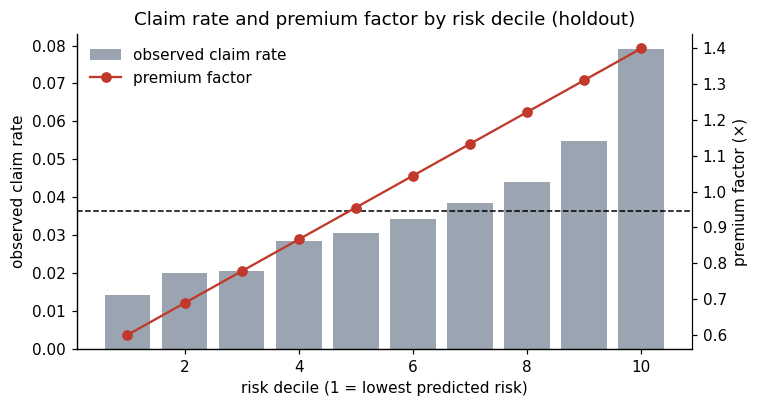

In [27]:
fig, ax1 = plt.subplots(figsize=(7, 3.8))
ax1.bar(tab.index.astype(int), tab.claim_rate, color="#9aa5b1", label="observed claim rate")
ax1.axhline(y_hold.mean(), ls="--", lw=1, color="k")
ax1.set_xlabel("risk decile (1 = lowest predicted risk)"); ax1.set_ylabel("observed claim rate")
ax2 = ax1.twinx(); ax2.plot(tab.index.astype(int), tab.premium_factor, marker="o", color="#c0392b", label="premium factor")
ax2.set_ylabel("premium factor (×)"); ax2.spines["right"].set_visible(True)
ax1.set_title("Claim rate and premium factor by risk decile (holdout)")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, frameon=False, loc="upper left")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/09_decile_premium.png"); plt.show()

In [28]:
# what the brief asked for versus what the signal supports
req, got = 0.65, RESULTS["holdout"]["capture_5pct"]
print(f"brief: top 5% of policies should contain {req:.0%} of claims")
print(f"holdout: top 5% contains {got:.1%} of claims  ({got/0.05:.1f}x random)")
RESULTS["brief_capture_target"], RESULTS["brief_capture_gap"] = req, round(float(req - got), 4)

brief: top 5% of policies should contain 65% of claims
holdout: top 5% contains 12.8% of claims  (2.6x random)


### Scoring the unlabeled policy file

`test.gz` has no outcomes, so it plays the role of the book to be priced. Before scoring it, an adversarial check confirms it comes from the same distribution as the training data: a classifier asked to tell the two files apart should not be able to.

In [29]:
n = 100_000
a = add_indicators(X_dev.drop(columns=calc_cols), X_dev).sample(n, random_state=1)
b = add_indicators(test[FEATURES].drop(columns=calc_cols), test[FEATURES]).sample(n, random_state=1)
adv = pd.concat([a.assign(_src=0), b.assign(_src=1)]).reset_index(drop=True)
adv_oof = run_cv(adv.drop(columns="_src"), adv["_src"], {**BASE_PARAMS, "n_estimators": 100}, n_folds=3)
adv_auc = roc_auc_score(adv["_src"], adv_oof)
RESULTS["adversarial_auc"] = round(float(adv_auc), 4)
print(f"train-vs-test adversarial AUC: {adv_auc:.4f}  (0.5 = indistinguishable)")

train-vs-test adversarial AUC: 0.5012  (0.5 = indistinguishable)


In [30]:
X_test_final = add_indicators(test[FEATURES].drop(columns=calc_cols), test[FEATURES])
for c in TE_COLS:
    X_test_final[c + "_te"] = target_encode(X_dev_final[c], y_dev, X_test_final[c]).values
p_test = final_model.predict_proba(X_test_final[X_dev_final.columns])[:, 1]

edges = np.quantile(p_hold, np.linspace(0, 1, 11)); edges[0], edges[-1] = -np.inf, np.inf
scores = pd.DataFrame({"id": test["id"], "claim_probability": p_test.round(5),
                       "risk_decile": pd.cut(p_test, edges, labels=range(1, 11)).astype(int)})
scores["premium_factor"] = scores.risk_decile.map(dict(zip(range(1, 11), tab.premium_factor.round(3))))
scores.to_csv(f"{OUT_DIR}/policy_scores.csv", index=False)
scores.head()

,id,claim_probability,risk_decile,premium_factor
0,0,0.02456,3,0.778
1,1,0.03011,5,0.956
2,2,0.02451,3,0.778
3,3,0.01414,1,0.600
4,4,0.03652,7,1.133


## 11. Interpretability

A regulated product needs to say which factors move a premium. Feature importance is measured by permutation on the holdout: shuffle one column, re-score, and read the AUC drop. This is preferred to the model's internal gain because it is measured on unseen data, and because the correlated `car` cluster (section 5.3) splits internal credit across its members. The cluster is therefore also permuted as a block.

In [31]:
cols = list(X_dev_final.columns)
pi = permutation_importance(final_model, X_hold_final[cols], y_hold, scoring="roc_auc",
                            n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=cols).sort_values(ascending=False)

car_cluster = sorted({a for a, b, _ in pairs} | {b for a, b, _ in pairs})
rng = np.random.default_rng(RANDOM_STATE); drops = []
for _ in range(3):
    Xs = X_hold_final[cols].copy(); perm = rng.permutation(len(Xs))
    Xs[car_cluster] = Xs[car_cluster].values[perm]
    drops.append(hold_metrics["auc"] - roc_auc_score(y_hold, final_model.predict_proba(Xs)[:, 1]))
imp_block = float(np.mean(drops))
RESULTS["permutation_importance_top15"] = imp.head(15).round(5).to_dict()
RESULTS["car_cluster"], RESULTS["car_cluster_block_importance"] = car_cluster, round(imp_block, 5)
print(f"correlated block {car_cluster}: joint AUC drop {imp_block:.4f} vs individual sum {imp[car_cluster].sum():.4f}")

correlated block ['ps_car_12', 'ps_car_13', 'ps_car_14', 'ps_car_15', 'ps_reg_02', 'ps_reg_03']: joint AUC drop 0.0328 vs individual sum 0.0219


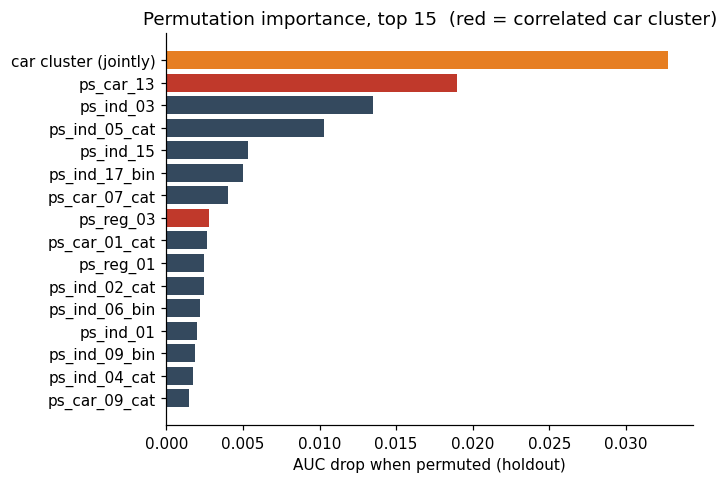

In [32]:
top = imp.head(15)[::-1]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.barh(top.index, top.values, color=["#c0392b" if c in car_cluster else "#34495e" for c in top.index])
ax.barh(["car cluster (jointly)"], [imp_block], color="#e67e22")
ax.set_xlabel("AUC drop when permuted (holdout)"); ax.set_title("Permutation importance, top 15  (red = correlated car cluster)")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/10_permutation_importance.png"); plt.show()

## 12. Export

In [35]:
RESULTS["experiments"] = {k: {m: round(float(v), 4) for m, v in d.items()} for k, d in EXPERIMENTS.items()}
with open(f"{OUT_DIR}/results.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
print("written outputs/results.json,", len(json.dumps(RESULTS)), "bytes")
print("figures:", sorted(os.listdir(FIG_DIR)))

written outputs/results.json, 7362 bytes
figures: ['01_target_balance.png', '02_missing_vs_target.png', '03_single_feature_auc.png', '04_correlation_car_reg.png', '05_imbalance_calibration.png', '06_early_stopping.png', '07_roc_pr_holdout.png', '08_calibration_lift_holdout.png', '09_decile_premium.png', '10_permutation_importance.png']
